### Fera formidável 4.10 - O caixeiro que prefere cidades ímpares

Aluno: Lucas Nascimento da Silva

#### Enunciado:
Objetivo: Encontre o caminho de menor distância no problema do caixeiro viajante
que prefere cidades ímpares e mostre ele de forma gráfica.

Considerações do experimento: Considere um número n ≥ 7 de coordenadas
(x, y) de cidades (cada cidade ocupa uma posição (x, y) diferente). Você pode gerar as
coordenadas de forma aleatória ou simplesmente usar as coordenadas que desejar. O
caixeiro só anda em linha reta e apenas entre duas cidades. O caixeiro começa e termina
seu trajeto na mesma cidade e, fora a cidade inicial, ele não visita nenhuma outra cidade
mais de uma vez. Além disso, atribua um número inteiro para cada uma das n cidades que
o caixeiro irá visitar, iniciando a contagem pelo número zero e aumentando esse número
de 1 em 1. O caixeiro deverá necessariamente visitar primeiro as cidades com números
ímpares antes das cidades com números pares. A cidade de número zero deve ser a cidade
inicial.

### Introdução 

Para utilizar algoritmos genéticos nessa situação a minha ideia principal foi fazer com que em nenhum momento o algoritmo trabalhasse com indivíduos inválidos. E para fazer isso, o primeiro passo é criar apenas indivíduos válidos, o que foi feito por meio da função `cria_candidato_caixeiro_impar_par` que separa as cidades pelas ímpares e pelas pares (com excessão da cidade 0), após é usada a função `random.shuffle` para embaralhar as cidades enquanto elas ainda estão separadas em ímpares e pares, por fim, é necessário apenas definir o caminho concatenado uma lista contendo a "Cidade 0" com as cidades ímpares e, por fim, as cidades pares. 

No cruzamento também é necessário fazer mudanças, essas mudanças foram feitas implementando uma nova função chamada `cruzamento_impar_par` que separa cada pai e mãe na parte par e na parte ímpar de cada um deles e cruza, pela função `cruzamento_ordenado`, a parte par do pai com a parte par da mãe, o mesmo ocorre para a parte impar. Após isso, é necessário apenas formar o filho, concatenando a lista com a "Cidade 0" com a parte impar do pai e com a parte par do pai, o mesmo ocorre para a mãe. 

Na mutação a ideia é adaptar a função `mutacao_troca` criando a função `mutacao_troca_par_impar` que sorteia o gene1, se esse gene1 pertencer à parte impar do indivíduo ele gera um gene2 que também pertence à parte impar do indivíduo, e o mesmo ocorre para a parte par.

### Importando funções

In [13]:
from functools import partial

from funcoes import plota_cidades
from funcoes import plota_trajeto
from funcoes import cria_cidades

from funcoes import populacao_caixeiro_impar_par as cria_populacao
from funcoes import funcao_objetivo_pop_caixeiro
from funcoes import funcao_objetivo_caixeiro
from funcoes import selecao_torneio_min as funcao_selecao
from funcoes import cruzamento_impar_par as funcao_cruzamento
from funcoes import mutacao_troca_par_impar as funcao_mutacao

### Definindo as constantes

In [25]:
NUM_CIDADES = 9
CIDADES = cria_cidades(NUM_CIDADES)

TAMANHO_POPULACAO = 100
NUM_GERACOES = 500
CHANCE_DE_CRUZAMENTO = 0.5
CHANCE_DE_MUTACAO = 0.05
TAMANHO_TORNEIO = 3

### Plotando as cidades

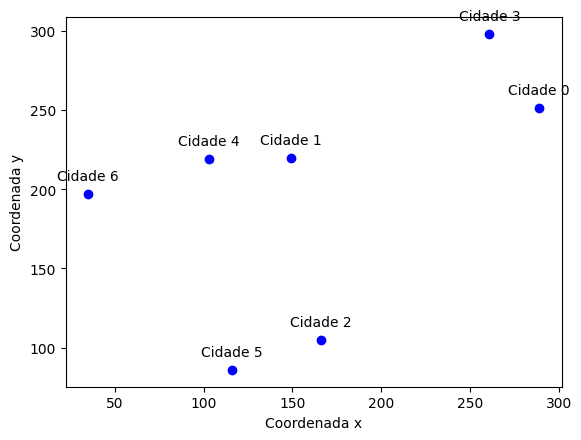

In [38]:
plota_cidades(CIDADES)

In [39]:
individuo = CIDADES
individuo

{'Cidade 0': (289, 251),
 'Cidade 1': (149, 220),
 'Cidade 2': (166, 105),
 'Cidade 3': (261, 298),
 'Cidade 4': (103, 219),
 'Cidade 5': (116, 86),
 'Cidade 6': (35, 197)}

### Mostrando o formato dos indivíduos

Observe que o indivíduo 0, assim como todos os demais indivíduos, da população segue o formato pedido no enunciado, ele começa indo na Cidade 0, passa pelas cidades ímpares e só aí passa pelas cidades pares.

In [42]:
populacao = cria_populacao(TAMANHO_POPULACAO, CIDADES)
populacao[0]

['Cidade 0',
 'Cidade 5',
 'Cidade 3',
 'Cidade 1',
 'Cidade 6',
 'Cidade 4',
 'Cidade 2']

### Definindo a função objetivo

Observe que a função objetivo não precisa mudar, uma vez que ainda queremos a menor distância e que os indivíduos são válidos a todo momento.

In [43]:
funcao_objetivo = partial(funcao_objetivo_pop_caixeiro, cidades=CIDADES)

### Evoluindo o algoritmo genético

In [34]:
hall_da_fama = []

for n in range(NUM_GERACOES):
    
    # Seleção
    fitness = funcao_objetivo(populacao)        
    selecionados = funcao_selecao(populacao, fitness, TAMANHO_TORNEIO)
    
    # Cruzamento
    proxima_geracao = []
    for pai, mae in zip(selecionados[::2], selecionados[1::2]):
        individuo1, individuo2 = funcao_cruzamento(pai, mae, CHANCE_DE_CRUZAMENTO)
        proxima_geracao.append(pai)
        proxima_geracao.append(mae)
    
    # Mutação
    funcao_mutacao(proxima_geracao, CHANCE_DE_MUTACAO)
    
    # Atualização do hall da fama
    fitness = funcao_objetivo(proxima_geracao)
        
    menor_fitness = min(fitness)
    indice = fitness.index(menor_fitness)
    hall_da_fama.append(proxima_geracao[indice])    
    
    # Encerramento
    populacao = proxima_geracao

### Encontrando o melhor indivíduo e plotando o caminho que ele realiza.

Melhor individuo obtido por algoritmos genéticos:
['Cidade 0', 'Cidade 3', 'Cidade 5', 'Cidade 1', 'Cidade 6', 'Cidade 4', 'Cidade 2'] com distância: 958.4790544407967



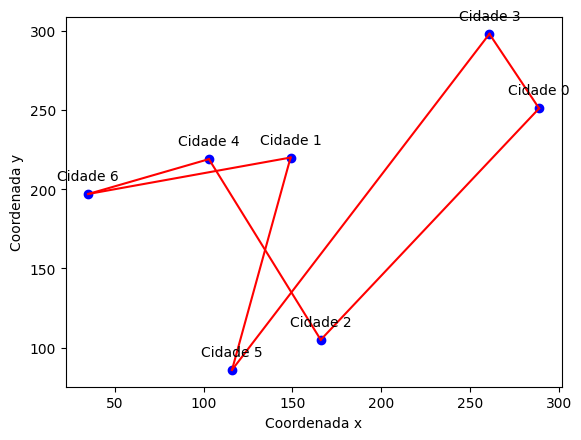

In [45]:
fitness = funcao_objetivo(hall_da_fama)
menor_fitness = min(fitness)
indice = fitness.index(menor_fitness)
melhor_individuo_observado = hall_da_fama[indice]
distancia = funcao_objetivo_caixeiro(melhor_individuo_observado, CIDADES)

print("Melhor individuo obtido por algoritmos genéticos:")
print(melhor_individuo_observado, "com distância:", distancia)
print()

plota_trajeto(CIDADES, melhor_individuo_observado)

### Conclusão

O problema foi resolvido de forma simples, foi interessante perceber o quão bom é não precisar trabalhar com indivíduos inválidos. De uma maneira geral as únicas mudanças necessárias ocorreram apenas na criação, mutação e cruzamento dos indivíduos, que poderiam mudar o formato dos indivíduos. 

### Referências

1. Cassar, Daniel R. Material didático algoritmos genéticos do ano de 2025.